I will be varying $\mu$ and $\Psi^\prime$ as my main variations, $dk$ and $B$ are secondary. $R$ and $A_0$ are fixed. $k0$ is fixed for now, varied later. I may need to set the endpoint of integration above where it is to get a good sample of period estimates for averaging, dependent on the parameters. 

In [1]:
#--LIBRARIES--------

import eelib
from eelib import pi

import numpy as np
import pickle
import pandas as pd
from sklearn.linear_model import LinearRegression

#plotting
import matplotlib.pyplot as plt
import seaborn as sns #statistical data visualization

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-6

#n = 10000 # ~100000 = 12 hrs
#n_dk = 2
#n_k0 = 2
n_B = 4
n_g = 11
n_m = 5

b_r  = (0.7, 1.0) # B here is B*R, since varying R will alter k, which I don't want
dk_r = (0.1, 0.9)
mu_r = (-7.5, -5.5) #1.0e-8 to 1.0e-5

#k0_r #later ....

pr = 200
n = 20

num_l = [n_m, n_B, n_g]


In [3]:
#--CODE--

#make loop, grid, or system
gridl = eelib.grid_slow_osc(R, B, dk, mu)

gridl.makeGridPoints(mu=mu_r, B=b_r, num = num_l)
gridl.gridSlowOsc()

Begin grid build:  0.0
Number of periods to calculate: 2420
mu: 0, dk: 0, Time: 0.0
mu: 1, dk: 0, Time: 29964.033932209015
mu: 2, dk: 0, Time: 59028.79977464676
mu: 3, dk: 0, Time: 87883.56496977806
mu: 4, dk: 0, Time: 116821.89009165764
Done grid build:  146684.96000933647


In [4]:
# since this takes a while to run and is used for a while, it is best to save a copy of the data
file = open('grid008', 'ab')
pickle.dump(gridl, file)
file.close()

# Variables

In [ ]:
# Pull the grids of values from our object

# independent variables
B_g = gridl.mfs  # B (for B * R)
#dk_g = gridl.ewd    # k
mu_g = gridl.nls   # mu
#amp = gridl.amp
dgrid = gridl.d0_grid

# dependent variables
fot = gridl.slow_osc_t[:,0,:,0,0,0,:,:]

#fot0 = gridl.fast_osc_t_0[:,:,:,0,0,0,:,:]

In [54]:
# Here we are changing the format of variable storage
# This is intended for use with pandas
# Columns are parameter / variable values here

size = np.shape(fot.flatten())[0]
print(size)
npaf = np.zeros((size, 6))

sz = [n_dk*n_B*n_g**2, n_B*n_g**2, n_g **2, n_g, 1]

for imu in range(n_m):
    for ik in range(n_dk):
        for ib in range(n_B):
            for idr in range(n_g):
                for idi in range(n_g):
                    ind = imu*sz[0]+ik*sz[1]+ib*sz[2]+idr*sz[3]+idi
                    #npaf[ind, 0] = mfp[im]
                    #npaf[ind, 1] = ew[ik]
                    npaf[ind, 0] = mu_g[imu]
                    npaf[ind, 1] = dk_g[ik]
                    npaf[ind, 2] = B_g[ib]
                    npaf[ind, 3] = np.real(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 4] = np.imag(dgrid[idr, idi]) / (eelib.kFAu + dk_g[ik]/R /2.0)
                    npaf[ind, 5] = fot[imu, ik, ib, idr, idi]-pi / (2*B_g[ib]*R*eelib.R_max*eelib.phi0inv*eelib.B_max)

32


In [49]:
pi / (2*.2*R*eelib.R_max*eelib.phi0inv*eelib.B_max)

7.953207109468959e-07

In [55]:
# now as a pandas dataframe
dfa = pd.DataFrame(npaf, columns = ["mu", "dk", "B", "D re", "D im", "T slow"])

# and to show it
dfa

,mu,dk,B,D re,D im,T slow
0,1.000000e-08,0.1,0.5,-1.38081,-1.38081,9.615275e-10
1,1.000000e-08,0.1,0.5,1.38081,-1.38081,9.615222e-10
2,1.000000e-08,0.1,0.5,-1.38081,1.38081,-9.583377e-10
3,1.000000e-08,0.1,0.5,1.38081,1.38081,-9.583364e-10
4,1.000000e-08,0.1,1.0,-1.38081,-1.38081,2.407814e-10
5,1.000000e-08,0.1,1.0,1.38081,-1.38081,2.407758e-10
6,1.000000e-08,0.1,1.0,-1.38081,1.38081,-2.391955e-10
7,1.000000e-08,0.1,1.0,1.38081,1.38081,-2.414868e-10
8,1.000000e-08,0.9,0.5,-1.38081,-1.38081,9.508775e-10
9,1.000000e-08,0.9,0.5,1.38081,-1.38081,9.508784e-10


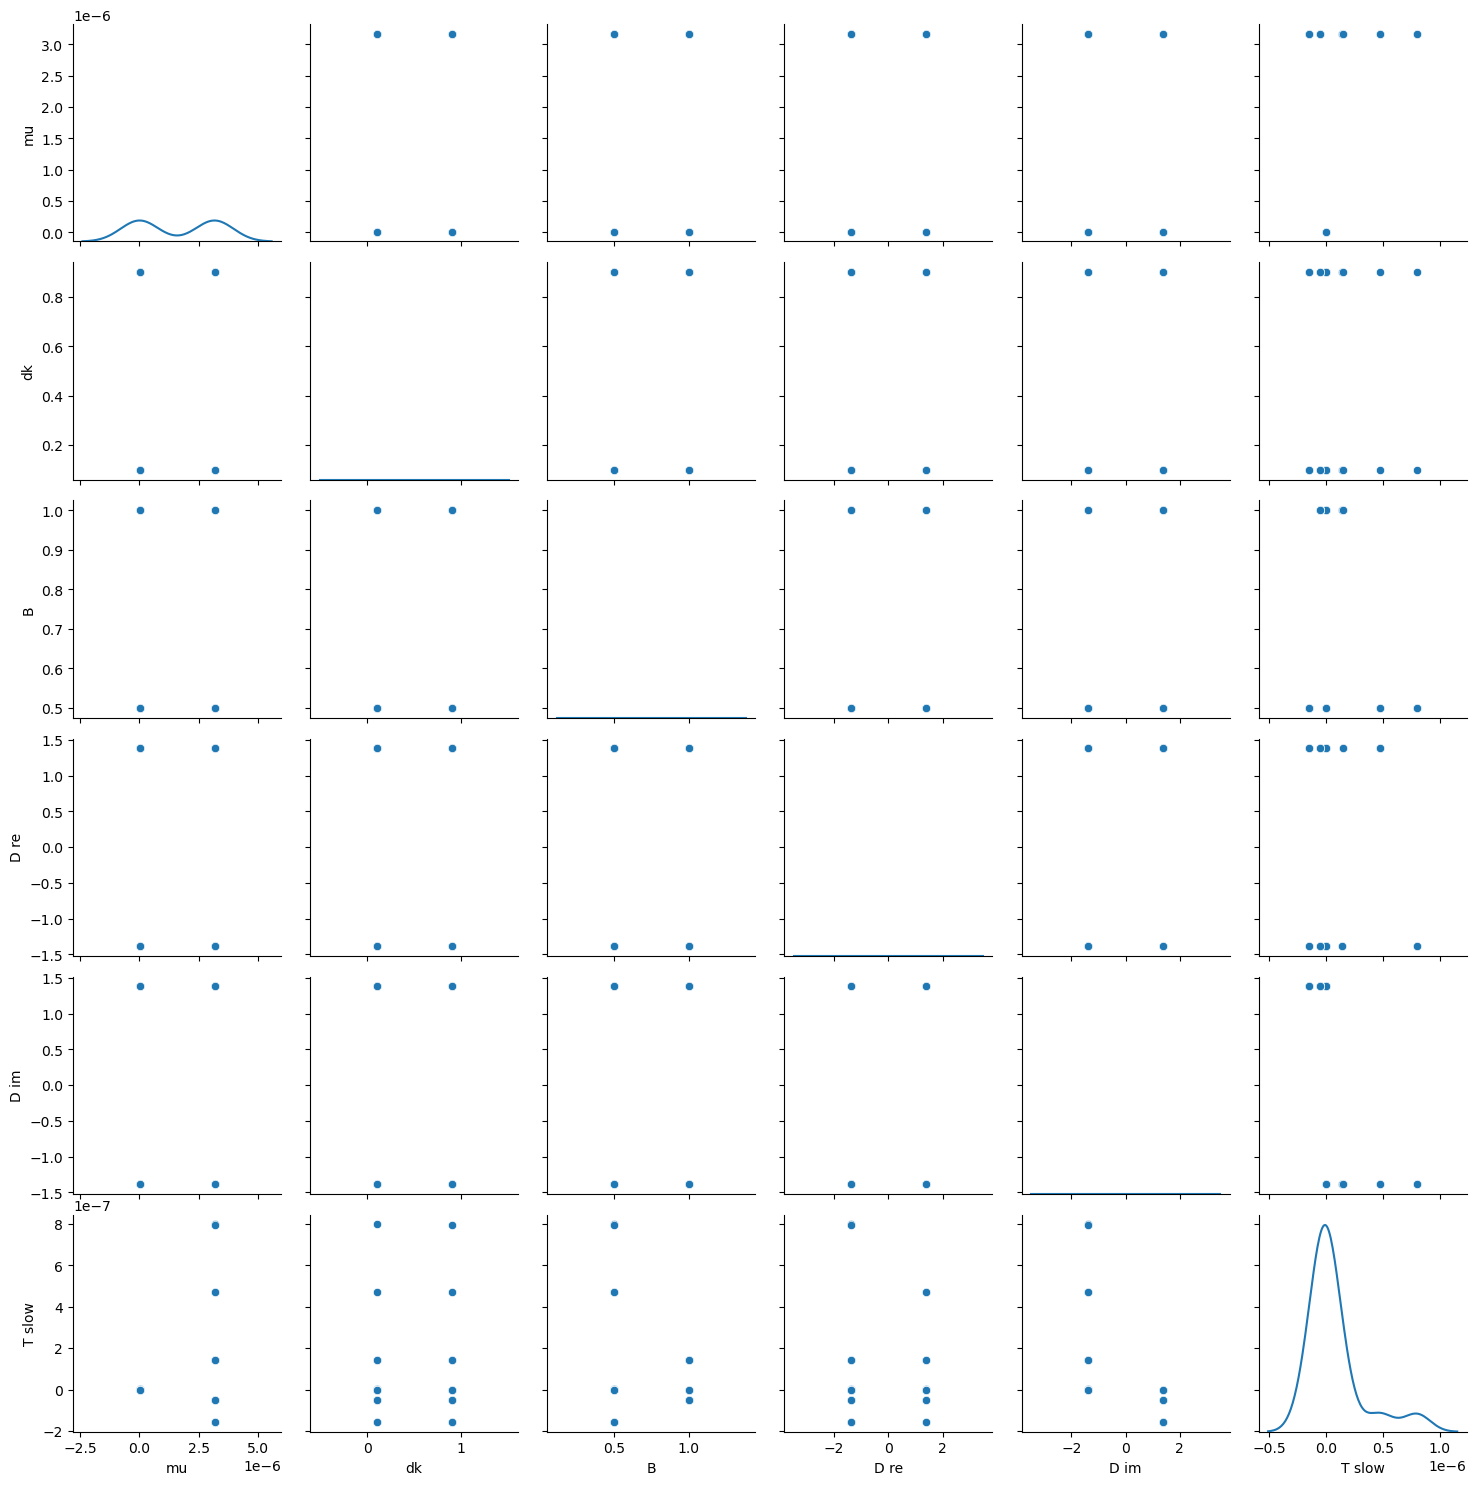

In [56]:
g = sns.PairGrid(dfa)
#g.map(sns.scatterplot)

g.map_diag(sns.kdeplot)
g.map_upper(sns.scatterplot)
g.map_lower(sns.scatterplot)
#g.map_diag(sns.kdeplot)

# Averaging of $M$

In [2]:
np.average([4.095961036825738e-07,
4.1430950209361265e-07,
4.0907260761456907e-07,
4.1535709565696636e-07,
4.085486787556734e-07,
4.153569168558949e-07,
4.216406029721245e-07,
4.0174088466808366e-07,
4.101204705877219e-07,
4.148333227661212e-07,
4.090724420771162e-07])

4.117862388845871e-07

In [3]:
np.std([4.095961036825738e-07,
4.1430950209361265e-07,
4.0907260761456907e-07,
4.1535709565696636e-07,
4.085486787556734e-07,
4.153569168558949e-07,
4.216406029721245e-07,
4.0174088466808366e-07,
4.101204705877219e-07,
4.148333227661212e-07,
4.090724420771162e-07])

4.97221122534263e-09

1%. Probably not an issue. I actually want a bit better, but that comes from error only from the averages of sets of two, so not an issue. I may need to increase the endpoint above $R$ for certain long period cases. I can find those separately later.